# OTA SNR Sweep — Postprocessing

**Frame structure** (16 symbols × 320 samples = 5120 samples/frame):
```
[Preamble][Pilot0][D0][D1]...[D11][Pilot1][Guard]
    0        1     2   3      13    14      15
```
- **Preamble** (sym 0): BPSK, xcorr frame sync
- **Pilot0** (sym 1): BPSK, LS channel estimation
- **D0–D11** (sym 2–13): QPSK data
- **Pilot1** (sym 14): BPSK, CFO tracking
- **Guard** (sym 15): zeros

Pipeline: preamble xcorr sync → pilot CFO → frame extraction → LS (pilot0) → ZF equalization → BER

## Cell 1 — Imports + Paths

In [8]:
import numpy as np
import glob, os, re, json
from scipy.signal import fftconvolve, find_peaks
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['font.size'] = 11

SWEEP_DIR   = '.'                    # notebook lives with the SigMF capture files
TX_FILE     = './tx_waveform.npz'
# run_sweep_master.py names captures rx_capture_cf<freq>_g<gain>.sigmf-data/.sigmf-meta
CENTER_FREQ = '3.5e9'
NOISE_FILE  = './rx_noise'            # SigMF basename, captured with TX off
SKIP_FRAMES = 5

def load_sigmf(base):
    """Load a SigMF capture (<base>.sigmf-data + .sigmf-meta) -> (samples, meta dict)."""
    for ext in ('.npz', '.sigmf-data', '.sigmf-meta'):
        if base.endswith(ext):
            base = base[: -len(ext)]
    samples = np.fromfile(f'{base}.sigmf-data', dtype=np.complex64)
    with open(f'{base}.sigmf-meta') as f:
        meta = json.load(f)
    return samples, meta


## Cell 2 — Load TX Reference

In [9]:
tx = np.load(TX_FILE)

# Load from npz keys → rename to clear variable names
preamble_freq = tx['sc2_freq']       # sym 0: xcorr sync
pilot0_freq   = tx['p0_freq']        # sym 1: channel estimation
pilot1_freq   = tx['p1_freq']        # sym 14: CFO tracking
data_bits     = tx['data_bits']
occupied_pos  = tx['occupied_pos']
FFT           = int(tx['fft'])
CP            = int(tx['cp'])
FRAME_LEN     = int(tx['frame_len'])
N_DATA_SYM    = int(tx['n_data_sym'])
SYM           = FFT + CP
occ_bins      = occupied_pos % FFT

# Preamble time-domain template for xcorr
preamble_td = np.fft.ifft(preamble_freq, n=FFT)
preamble_template = np.concatenate([preamble_td[-CP:], preamble_td]).astype(np.complex64)

QPSK_MAP = np.array([1+1j, -1+1j, 1-1j, -1-1j], dtype=np.complex64) / np.sqrt(2)

print(f'FFT={FFT}  CP={CP}  SYM={SYM}  frame={FRAME_LEN}')
print(f'{N_DATA_SYM} data sym x {len(occ_bins)} SCs = {N_DATA_SYM*len(occ_bins)*2} bits/frame')
print(f'Active subcarrier bins: {len(occ_bins)} / {FFT}')

FFT=256  CP=64  SYM=320  frame=5120
12 data sym x 192 SCs = 4608 bits/frame
Active subcarrier bins: 192 / 256


## Cell 3 — Noise Floor (active subcarriers only)

Noise power (active SCs): -49.6 dB


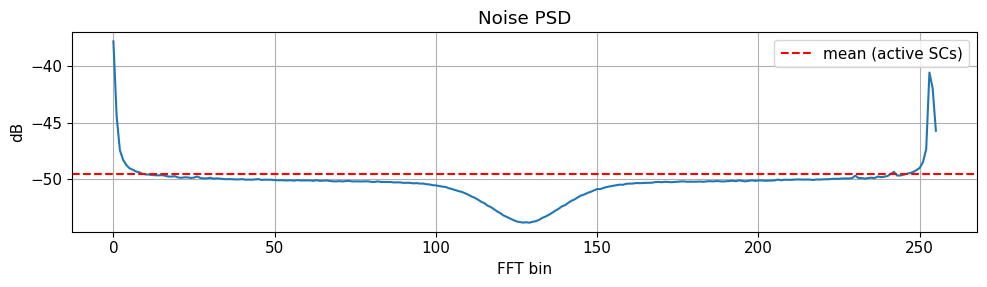

In [10]:
noise_samples, noise_meta = load_sigmf(NOISE_FILE)

# FFT the noise, average power per bin
n_blocks = len(noise_samples) // FFT
noise_fft = noise_samples[:n_blocks*FFT].reshape(n_blocks, FFT)
noise_spec = np.fft.fft(noise_fft, axis=1)
noise_pwr_per_bin = np.mean(np.abs(noise_spec)**2, axis=0)
noise_pwr_active  = float(np.mean(noise_pwr_per_bin[occ_bins]))

print(f'Noise power (active SCs): {10*np.log10(noise_pwr_active+1e-20):.1f} dB')

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(10*np.log10(noise_pwr_per_bin + 1e-20))
ax.axhline(10*np.log10(noise_pwr_active+1e-20), color='r', ls='--', label='mean (active SCs)')
ax.set_xlabel('FFT bin'); ax.set_ylabel('dB')
ax.set_title('Noise PSD'); ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()


## Cell 4 — QPSK Demodulator

In [11]:
def qpsk_demod(syms):
    bits = np.zeros(len(syms) * 2, dtype=np.int8)
    bits[0::2] = (syms.imag < 0).astype(np.int8)
    bits[1::2] = (syms.real < 0).astype(np.int8)
    return bits

## Cell 5 — Processing Pipeline

In [12]:
def process_capture(rx_path, skip=SKIP_FRAMES):
    samples, meta = load_sigmf(rx_path)
    rate = float(meta['global']['core:sample_rate'])
    clipped = bool(meta['global'].get('winlab:clipped', False))
    if clipped:
        print(f'  [clipped: peak={meta["global"].get("winlab:peak_sample", float("nan")):.3f}] ', end='')

    # 1. Preamble xcorr sync
    xcorr = np.abs(fftconvolve(samples, np.conj(preamble_template[::-1]), mode='valid'))
    peaks, _ = find_peaks(xcorr, height=0.5*np.max(xcorr), distance=int(FRAME_LEN*0.8))
    if len(peaks) < skip + 2:
        return None

    # 2. Pilot-based CFO estimation (pilot0 at sym 1, pilot1 at sym 14)
    cfos = []
    for fs in peaks:
        if fs + FRAME_LEN > len(samples): continue
        H_p0 = np.fft.fft(samples[fs+1*SYM+CP:fs+1*SYM+CP+FFT])[occ_bins] / pilot0_freq[occ_bins]
        H_p1 = np.fft.fft(samples[fs+14*SYM+CP:fs+14*SYM+CP+FFT])[occ_bins] / pilot1_freq[occ_bins]
        cfos.append(np.angle(np.sum(H_p1*np.conj(H_p0))) / (2*np.pi*13*SYM/rate))
    cfo = np.median(cfos) if cfos else 0.0

    # 3. CFO correction
    samples_c = samples * np.exp(-1j*2*np.pi*cfo/rate * np.arange(len(samples)))

    # 4. Frame extraction
    valid = (peaks >= 0) & (peaks + FRAME_LEN <= len(samples_c))
    starts = peaks[valid][skip:]
    nf = len(starts)
    if nf == 0: return None

    Y_pilot0 = np.zeros((nf, FFT), dtype=np.complex64)
    Y_data   = np.zeros((nf, N_DATA_SYM, FFT), dtype=np.complex64)
    for i, fs in enumerate(starts):
        Y_pilot0[i] = np.fft.fft(samples_c[fs+1*SYM+CP:fs+1*SYM+CP+FFT])
        for d in range(N_DATA_SYM):
            Y_data[i,d] = np.fft.fft(samples_c[fs+(2+d)*SYM+CP:fs+(2+d)*SYM+CP+FFT])

    # 5. LS channel estimation (from pilot0)
    H_ls = Y_pilot0[:, occ_bins] / pilot0_freq[occ_bins]

    # 6. Power-based SNR (active SCs only)
    sig_pwr_active = float(np.mean(np.abs(Y_pilot0[:, occ_bins])**2))
    snr_power_db = 10*np.log10(sig_pwr_active / (noise_pwr_active + 1e-20))

    # 7. Pilot-based SNR (variance method)
    H_ref = H_ls[0]
    H_aligned = np.zeros_like(H_ls)
    for i in range(nf):
        phi = np.angle(np.sum(H_ls[i] * np.conj(H_ref)))
        H_aligned[i] = H_ls[i] * np.exp(-1j*phi)
    H_mean = np.mean(H_aligned, axis=0)
    H_var  = np.mean(np.abs(H_aligned - H_mean)**2, axis=0)
    snr_per_sc = np.abs(H_mean)**2 / (H_var + 1e-20)
    snr_pilot_db = 10*np.log10(np.mean(snr_per_sc) + 1e-20)

    # 8. ZF equalization + BER
    total_err, total_bits = 0, 0
    eq_syms = []
    for i in range(nf):
        for d in range(N_DATA_SYM):
            X_hat = Y_data[i, d, occ_bins] / (H_ls[i] + 1e-20)
            total_err += np.sum(qpsk_demod(X_hat) != data_bits[d])
            total_bits += len(data_bits[d])
            eq_syms.append(X_hat)
    ber = total_err / total_bits if total_bits else 1.0

    return dict(
        n_frames=nf, cfo=cfo, clipped=clipped,
        snr_power_db=snr_power_db, snr_pilot_db=snr_pilot_db,
        ber=ber, total_bits=total_bits,
        H_ls=H_ls, snr_per_sc=snr_per_sc,
        eq_syms=np.concatenate(eq_syms),
    )

## Cell 6 — Process All Captures

In [13]:
files = sorted(glob.glob(os.path.join(SWEEP_DIR, f'rx_capture_cf{CENTER_FREQ}_g*.sigmf-data')))
get_gain = lambda f: int(re.search(r'_g(\d+)\.sigmf-data$', os.path.basename(f)).group(1))
files = sorted(files, key=get_gain, reverse=True)

print(f'Found {len(files)} captures\n')

results = []
for f in files:
    txg = get_gain(f)
    print(f'  txg={txg} dB ... ', end='', flush=True)
    r = process_capture(f)
    if r is None:
        print('FAILED'); continue
    r['tx_gain'] = txg
    results.append(r)
    print(f"{r['n_frames']} frames | SNR(pwr) {r['snr_power_db']:.1f} dB | BER {r['ber']:.2e}")


Found 4 captures

  txg=15 dB ... 1947 frames | SNR(pwr) 62.2 dB | BER 0.00e+00
  txg=10 dB ... 1947 frames | SNR(pwr) 57.1 dB | BER 5.58e-01
  txg=5 dB ... 1948 frames | SNR(pwr) 52.2 dB | BER 5.61e-01
  txg=0 dB ... 1947 frames | SNR(pwr) 47.1 dB | BER 0.00e+00


## Cell 7 — Summary Table

In [14]:
print(f"{'='*68}")
print(f"  SNR SWEEP SUMMARY — cf{CENTER_FREQ}")
print(f"{'='*68}")
print(f"  {'TXg':>4s}  {'Frames':>6s}  {'SNR(pwr)':>9s}  {'SNR(pilot)':>11s}  "
      f"{'BER':>10s}  {'CFO Hz':>8s}")
print(f"  {'-'*4}  {'-'*6}  {'-'*9}  {'-'*11}  {'-'*10}  {'-'*8}")
for r in results:
    print(f"  {r['tx_gain']:>4d}  {r['n_frames']:>6d}  {r['snr_power_db']:>9.1f}  "
          f"{r['snr_pilot_db']:>11.1f}  {r['ber']:>10.2e}  {r['cfo']:>8.1f}")
print(f"\n  Noise floor (active SCs): {10*np.log10(noise_pwr_active+1e-20):.1f} dB")
print(f"{'='*68}")


  SNR SWEEP SUMMARY — cf3.5e9
   TXg  Frames   SNR(pwr)   SNR(pilot)         BER    CFO Hz
  ----  ------  ---------  -----------  ----------  --------
    15    1947       62.2         27.8    0.00e+00     -52.0
    10    1947       57.1         19.4    5.58e-01    -403.5
     5    1948       52.2         19.4    5.61e-01    -234.9
     0    1947       47.1         19.4    0.00e+00     457.4

  Noise floor (active SCs): -49.6 dB


## Cell 8 — BER vs TX Gain / SNR

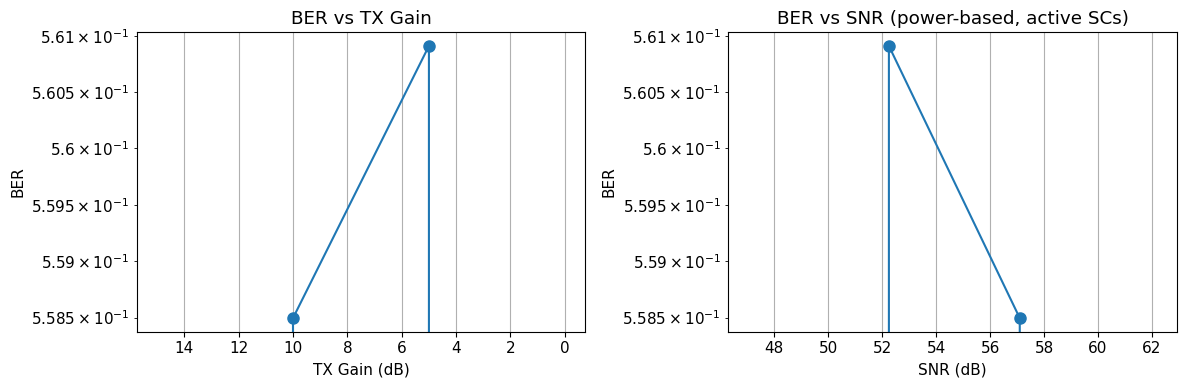

In [15]:
tx_gains = [r['tx_gain']      for r in results]
snrs     = [r['snr_power_db'] for r in results]
bers     = [r['ber']          for r in results]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.semilogy(tx_gains, bers, 'o-', markersize=8)
ax1.set_xlabel('TX Gain (dB)'); ax1.set_ylabel('BER')
ax1.set_title('BER vs TX Gain'); ax1.grid(True)
ax1.invert_xaxis()

ax2.semilogy(snrs, bers, 'o-', markersize=8)
ax2.set_xlabel('SNR (dB)'); ax2.set_ylabel('BER')
ax2.set_title('BER vs SNR (power-based, active SCs)'); ax2.grid(True)

plt.tight_layout(); plt.show()

## Cell 9 — Constellation

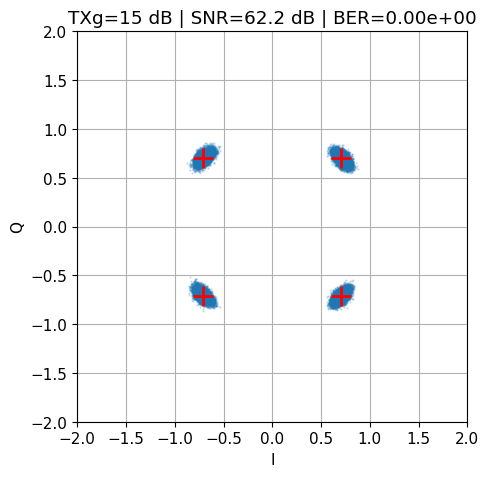

In [16]:
# 0 = highest gain, -1 = lowest
IDX = 0
r = results[IDX]
eq = r['eq_syms']
if len(eq) > 50000:
    eq = eq[np.random.choice(len(eq), 50000, replace=False)]

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(eq.real, eq.imag, s=0.5, alpha=0.2)
for pt in QPSK_MAP:
    ax.plot(pt.real, pt.imag, 'r+', markersize=15, markeredgewidth=2)
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_aspect('equal'); ax.grid(True)
ax.set_title(f"TXg={r['tx_gain']} dB | SNR={r['snr_power_db']:.1f} dB | BER={r['ber']:.2e}")
ax.set_xlabel('I'); ax.set_ylabel('Q')
plt.tight_layout(); plt.show()

## Cell 10 — Channel Frequency Response

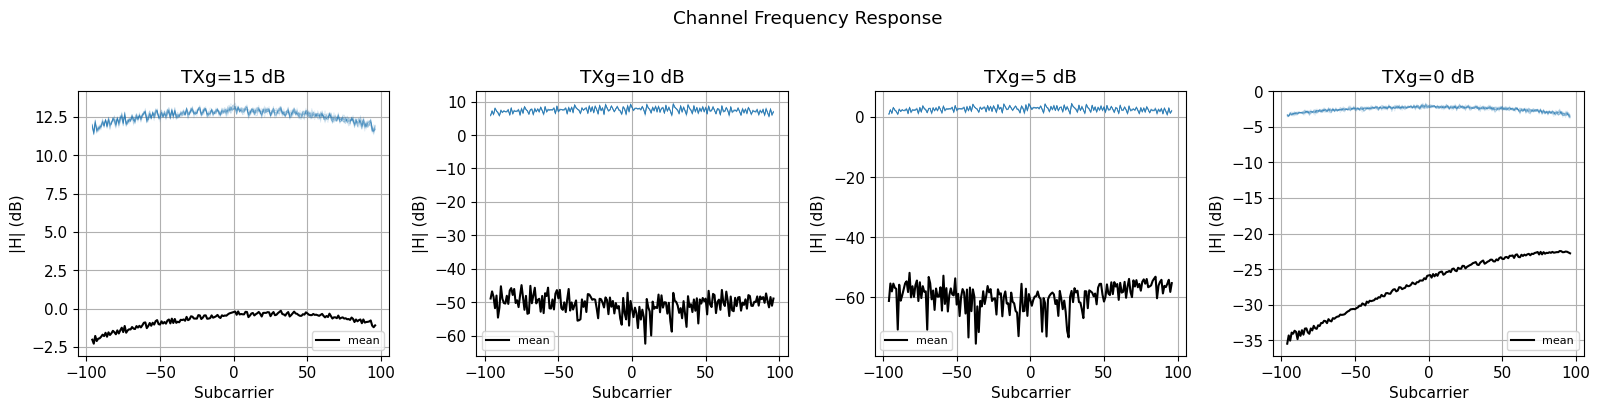

In [19]:
fig, axes = plt.subplots(1, len(results), figsize=(4*len(results), 4), squeeze=False)

for idx, r in enumerate(results):
    ax = axes[0, idx]
    H = r['H_ls']
    for j in range(min(20, H.shape[0])):
        ax.plot(occupied_pos, 20*np.log10(np.abs(H[j])+1e-20),
                alpha=0.15, color='C0', linewidth=0.5)
    ax.plot(occupied_pos, 20*np.log10(np.abs(np.mean(H, axis=0))+1e-20),
            'k-', linewidth=1.5, label='mean')
    ax.set_title(f"TXg={r['tx_gain']} dB")
    ax.set_xlabel('Subcarrier'); ax.set_ylabel('|H| (dB)')
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle('Channel Frequency Response', y=1.02)
plt.tight_layout(); plt.show()

## Cell 11 — Per-Subcarrier SNR

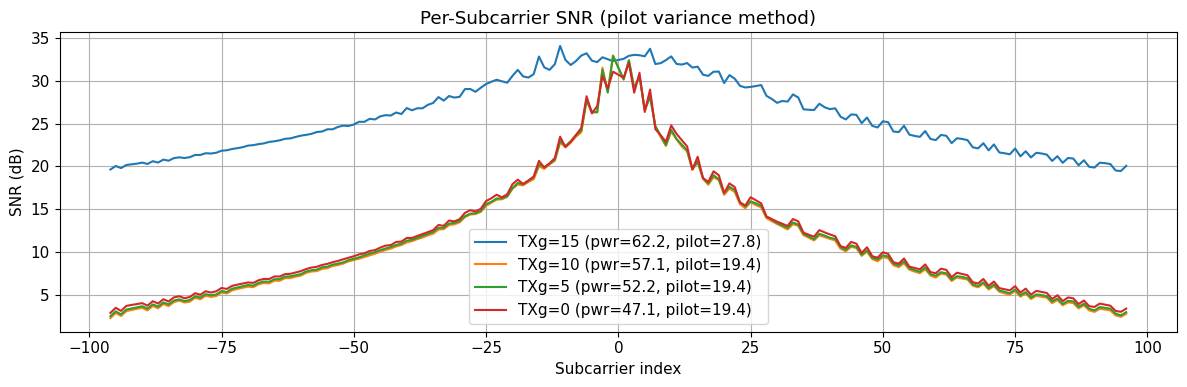

In [20]:
fig, ax = plt.subplots(figsize=(12, 4))

for r in results:
    ax.plot(occupied_pos, 10*np.log10(r['snr_per_sc']+1e-20),
            label=f"TXg={r['tx_gain']} (pwr={r['snr_power_db']:.1f}, pilot={r['snr_pilot_db']:.1f})")

ax.set_xlabel('Subcarrier index'); ax.set_ylabel('SNR (dB)')
ax.set_title('Per-Subcarrier SNR (pilot variance method)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()